# Chronic Kidney Disease 
### This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.

#### Basic information of dataset

age → Age ,
bp → Blood Pressure ,
sg → Specific Gravity ,
al → Albumin ,
su → Sugar ,
rbc → Red Blood Cells ,
pc → Pus Cell ,
pcc → Pus Cell Clumps ,
ba → Bacteria ,
bgr → Blood Glucose Random ,
bu → Blood Urea ,
sc → Serum Creatinine ,
sod → Sodium ,
pot → Potassium ,
hemo → Hemoglobin ,
pcv → Packed Cell Volume ,
wbcc → White Blood Cell Count ,
rbcc → Red Blood Cell Count ,
htn → Hypertension ,
dm → Diabetes Mellitus ,
cad → Coronary Artery Disease ,
appet → Appetite ,
pe → Pedal Edema ,
ane → Anemia ,
class → Target (ckd / notckd)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(
    '/home/user/Desktop/Kidney/notebook/data/chronic_kidney_disease.csv',
    skiprows=29,
    header=None,
    names=[
        'age','bp','sg','al','su','rbc','pc','pcc','ba',
        'bgr','bu','sc','sod','pot','hemo','pcv','wbcc',
        'rbcc','htn','dm','cad','appet','pe','ane','class'
    ],
    na_values='?',
    on_bad_lines='skip'
)

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
df.shape

(397, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     388 non-null    float64
 1   bp      385 non-null    float64
 2   sg      350 non-null    float64
 3   al      351 non-null    float64
 4   su      348 non-null    float64
 5   rbc     247 non-null    object 
 6   pc      332 non-null    object 
 7   pcc     393 non-null    object 
 8   ba      393 non-null    object 
 9   bgr     354 non-null    float64
 10  bu      378 non-null    float64
 11  sc      380 non-null    float64
 12  sod     312 non-null    float64
 13  pot     311 non-null    float64
 14  hemo    345 non-null    float64
 15  pcv     328 non-null    object 
 16  wbcc    293 non-null    object 
 17  rbcc    268 non-null    object 
 18  htn     395 non-null    object 
 19  dm      395 non-null    object 
 20  cad     395 non-null    object 
 21  appet   396 non-null    object 
 22  pe

In [5]:
print(df.columns)

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'class'],
      dtype='object')


In [6]:
df.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,388.000000,385.000000,350.000000,351.000000,348.000000,354.000000,378.000000,380.000000,312.000000,311.000000,345.000000
mean,51.456186,76.467532,1.017429,1.017094,0.433908,147.864407,57.608995,3.088289,137.508013,4.630868,12.520870
std,17.133935,13.711674,0.005724,1.352138,1.078316,79.290292,50.651072,5.760989,10.418992,3.198409,2.917514
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,54.500000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.600000
75%,64.250000,80.000000,1.020000,2.000000,0.000000,162.750000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [7]:
df.isnull().sum()

age        9
bp        12
sg        47
al        46
su        49
rbc      150
pc        65
pcc        4
ba         4
bgr       43
bu        19
sc        17
sod       85
pot       86
hemo      52
pcv       69
wbcc     104
rbcc     129
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo'], dtype='object')
Categorical Features: Index(['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'class'],
      dtype='object')


In [10]:
pd.set_option('display.max_columns', None)
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


- You should convert pcv, wbcc, and rbcc to numeric:

In [11]:
print("Unique values in 'pcv' column:", df['pcv'].unique())
print("Number of unique values in 'pcv' column:", df['pcv'].nunique())

print("Unique values in 'wbcc' column:", df['wbcc'].unique())
print("Number of unique values in 'wbcc' column:", df['wbcc'].nunique())

print("Unique values in 'rbcc' column:", df['rbcc'].unique())
print("Number of unique values in 'rbcc' column:", df['rbcc'].nunique())

Unique values in 'pcv' column: ['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' nan '16' '24' '37' '30'
 '34' '40' '45' '27' '48' '\t?' '14' '22' '52' '18' '42' '17' '46' '23'
 '19' '25' '41' '26' '15' '21' '43' '20' '\t43' '47' '9' '49' '50' '53'
 '51' '54']
Number of unique values in 'pcv' column: 44
Unique values in 'wbcc' column: ['7800' '6000' '7500' '6700' '7300' nan '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9800' '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300'
 '7200' '7700' '14600' '6300' '\t6200' '7100' '11800' '9400' '5500' '5800'
 '13200' '12500' '5600' '7000' '11900' '10400' '10700' '12700' '6800'
 '6500' '13600' '10200' '9000' '14900' '8200' '15200' '5000' '16300'
 '12400' '\t8400' '10500' '4200' '4700' '10900' '8100' '9500' '2200'
 '12800' '11200' '19100' '\t?' '12300' '16700' '2600' '26400' '8800'
 '7400' '4900' '8000' '12000' '15700' '4100' '5700' '11500' '5400' '10800'
 '9900' '5200' '5

In [12]:
num_cols = ['pcv', 'wbcc', 'rbcc']

for col in num_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('?', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(df[num_cols].dtypes)
df[num_cols].head()

pcv     float64
wbcc    float64
rbcc    float64
dtype: object


,pcv,wbcc,rbcc
0,44.0,7800.0,5.2
1,38.0,6000.0,NaN
2,31.0,7500.0,NaN
3,32.0,6700.0,3.9
4,35.0,7300.0,4.6


In [13]:
df[num_cols].isnull().sum()

pcv      70
wbcc    105
rbcc    130
dtype: int64

In [14]:
print("Unique values in 'pcv' column:", df['pcv'].unique())
print("Number of unique values in 'pcv' column:", df['pcv'].nunique())

print("Unique values in 'wbcc' column:", df['wbcc'].unique())
print("Number of unique values in 'wbcc' column:", df['wbcc'].nunique())

print("Unique values in 'rbcc' column:", df['rbcc'].unique())
print("Number of unique values in 'rbcc' column:", df['rbcc'].nunique())

Unique values in 'pcv' column: [44. 38. 31. 32. 35. 39. 36. 33. 29. 28. nan 16. 24. 37. 30. 34. 40. 45.
 27. 48. 14. 22. 52. 18. 42. 17. 46. 23. 19. 25. 41. 26. 15. 21. 43. 20.
 47.  9. 49. 50. 53. 51. 54.]
Number of unique values in 'pcv' column: 42
Unique values in 'wbcc' column: [ 7800.  6000.  7500.  6700.  7300.    nan  6900.  9600. 12100.  4500.
 12200. 11000.  3800. 11400.  5300.  9200.  6200.  8300.  8400. 10300.
  9800.  9100.  7900.  6400.  8600. 18900. 21600.  4300.  8500. 11300.
  7200.  7700. 14600.  6300.  7100. 11800.  9400.  5500.  5800. 13200.
 12500.  5600.  7000. 11900. 10400. 10700. 12700.  6800.  6500. 13600.
 10200.  9000. 14900.  8200. 15200.  5000. 16300. 12400. 10500.  4200.
  4700. 10900.  8100.  9500.  2200. 12800. 11200. 19100. 12300. 16700.
  2600. 26400.  8800.  7400.  4900.  8000. 12000. 15700.  4100.  5700.
 11500.  5400. 10800.  9900.  5200.  5900.  9300.  9700.  5100.  6600.]
Number of unique values in 'wbcc' column: 89
Unique values in 'rbcc' column: 

#### Handling missing values

In [15]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo',
       'pcv', 'wbcc', 'rbcc'],
      dtype='object')
Categorical Features: Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'class'],
      dtype='object')


In [16]:
df.isnull().sum().sum()

np.int64(1002)

In [17]:
df['age'] = df['age'].fillna(df['age'].mean())
df['bp'] = df['bp'].fillna(df['bp'].mean())
df['sg'] = df['sg'].fillna(df['sg'].mean())
df['al'] = df['al'].fillna(df['al'].mean())
df['su'] = df['su'].fillna(df['su'].mean())
df['pcv'] = pd.to_numeric(df['pcv'], errors='coerce')
df['pcv'] = df['pcv'].fillna(df['pcv'].mean())
df['wbcc'] = pd.to_numeric(df['wbcc'], errors='coerce')
df['wbcc'] = df['wbcc'].fillna(df['wbcc'].mean())
df['rbcc'] = pd.to_numeric(df['rbcc'], errors='coerce')
df['rbcc'] = df['rbcc'].fillna(df['rbcc'].mean())
df['bgr'] = df['bgr'].fillna(df['bgr'].mean())
df['bu'] = df['bu'].fillna(df['bu'].mean())
df['sc'] = df['sc'].fillna(df['sc'].mean())
df['sod'] = df['sod'].fillna(df['sod'].mean())
df['pot'] = df['pot'].fillna(df['pot'].mean())
df['hemo'] = df['hemo'].fillna(df['hemo'].mean())

In [18]:

df['rbc'] = df['rbc'].fillna(df['rbc'].mode()[0])
df['pc'] = df['pc'].fillna(df['pc'].mode()[0])
df['pcc'] = df['pcc'].fillna(df['pcc'].mode()[0])
df['ba'] = df['ba'].fillna(df['ba'].mode()[0])
df['htn'] = df['htn'].fillna(df['htn'].mode()[0])
df['dm'] = df['dm'].fillna(df['dm'].mode()[0])
df['cad'] = df['cad'].fillna(df['cad'].mode()[0])
df['appet'] = df['appet'].fillna(df['appet'].mode()[0])
df['pe'] = df['pe'].fillna(df['pe'].mode()[0])
df['ane'] = df['ane'].fillna(df['ane'].mode()[0])

In [19]:
df.isnull().sum().sum()


np.int64(0)

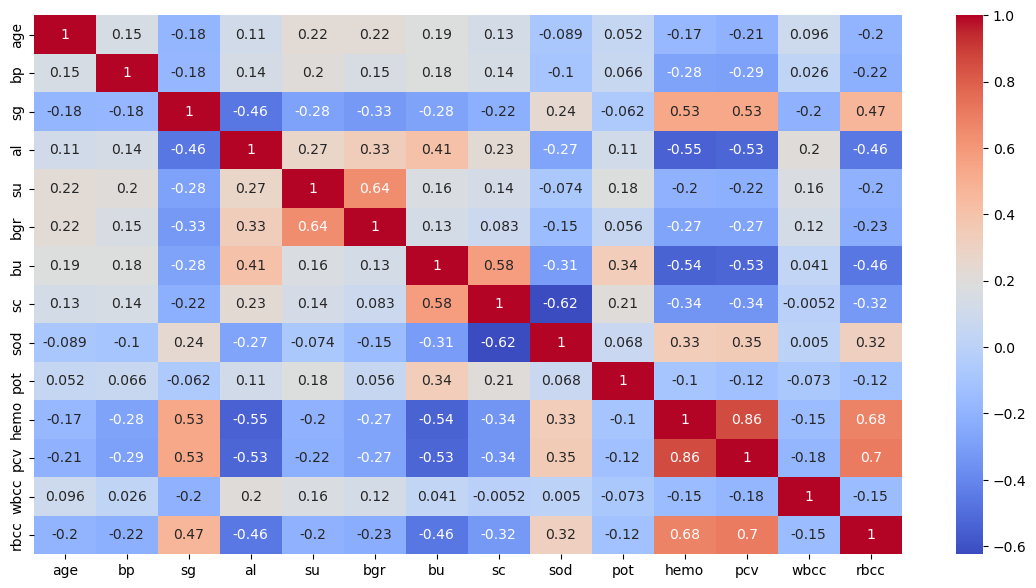

In [20]:
plt.figure(figsize=(14,7))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [21]:
columns =[ 'pc', 'pcc', 'ba','htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class','rbc']

for col in columns:
    print("=" * 50)
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False))
    print()


Column: pc
pc
normal      322
abnormal     75
Name: count, dtype: int64

Column: pcc
pcc
notpresent    356
present        41
Name: count, dtype: int64

Column: ba
ba
notpresent    375
present        22
Name: count, dtype: int64

Column: htn
htn
no     251
yes    146
Name: count, dtype: int64

Column: dm
dm
no       259
yes      132
\tno       3
\tyes      2
 yes       1
Name: count, dtype: int64

Column: cad
cad
no      361
yes      34
\tno      2
Name: count, dtype: int64

Column: appet
appet
good    315
poor     82
Name: count, dtype: int64

Column: pe
pe
no     322
yes     75
Name: count, dtype: int64

Column: ane
ane
no     337
yes     60
Name: count, dtype: int64

Column: class
class
ckd       246
notckd    149
ckd\t       2
Name: count, dtype: int64

Column: rbc
rbc
normal      350
abnormal     47
Name: count, dtype: int64



In [22]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [23]:

print(df['dm'].value_counts())
print(df['cad'].value_counts())
print(df['class'].value_counts())

dm
no     262
yes    135
Name: count, dtype: int64
cad
no     363
yes     34
Name: count, dtype: int64
class
ckd       248
notckd    149
Name: count, dtype: int64


In [24]:
print(categorical_features)

Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'class'],
      dtype='object')


In [25]:
df['rbc'] = df['rbc'].map({'normal': 0, 'abnormal': 1})
df['pc'] = df['pc'].map({'normal': 0, 'abnormal': 1})
df['pcc'] = df['pcc'].map({'notpresent': 0, 'present': 1})
df['ba'] = df['ba'].map({'notpresent': 0, 'present': 1})
df['htn'] = df['htn'].map({'no': 0, 'yes': 1})
df['dm'] = df['dm'].map({'no': 0, 'yes': 1})
df['cad'] = df['cad'].map({'no': 0, 'yes': 1})
df['appet'] = df['appet'].map({'poor': 0, 'good':1})
df['pe'] = df['pe'].map({'no': 0, 'yes': 1})
df['ane'] = df['ane'].map({'no': 0, 'yes': 1})
df['class'] = df['class'].map({'ckd':0,'notckd':1})
df.head(5)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,0,0,0,0,121.000000,36.0,1.2,137.508013,4.630868,15.4,44.0,7800.0,5.200000,1,1,0,1,0,0,0
1,7.0,50.0,1.020,4.0,0.0,0,0,0,0,147.864407,18.0,0.8,137.508013,4.630868,11.3,38.0,6000.0,4.702247,0,0,0,1,0,0,0
2,62.0,80.0,1.010,2.0,3.0,0,0,0,0,423.000000,53.0,1.8,137.508013,4.630868,9.6,31.0,7500.0,4.702247,0,1,0,0,0,1,0
3,48.0,70.0,1.005,4.0,0.0,0,1,1,0,117.000000,56.0,3.8,111.000000,2.500000,11.2,32.0,6700.0,3.900000,1,0,0,0,1,1,0
4,51.0,80.0,1.010,2.0,0.0,0,0,0,0,106.000000,26.0,1.4,137.508013,4.630868,11.6,35.0,7300.0,4.600000,0,0,0,1,0,0,0


In [26]:
df['class'].value_counts()


class
0    248
1    149
Name: count, dtype: int64

In [27]:
print(df.isnull().sum().sum())
print(df.dtypes)
print(df.head())

0
age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc        int64
pc         int64
pcc        int64
ba         int64
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn        int64
dm         int64
cad        int64
appet      int64
pe         int64
ane        int64
class      int64
dtype: object
    age    bp     sg   al   su  rbc  pc  pcc  ba         bgr    bu   sc  \
0  48.0  80.0  1.020  1.0  0.0    0   0    0   0  121.000000  36.0  1.2   
1   7.0  50.0  1.020  4.0  0.0    0   0    0   0  147.864407  18.0  0.8   
2  62.0  80.0  1.010  2.0  3.0    0   0    0   0  423.000000  53.0  1.8   
3  48.0  70.0  1.005  4.0  0.0    0   1    1   0  117.000000  56.0  3.8   
4  51.0  80.0  1.010  2.0  0.0    0   0    0   0  106.000000  26.0  1.4   

          sod       pot  hemo   pcv    wbcc      rbcc  htn  dm  cad  appet  \
0  137.508013  4.630868  15.4 

In [ ]:
df.to_csv("kidney_disease_cleaned.csv", index=False)

In [29]:
print(numerical_features)

Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo',
       'pcv', 'wbcc', 'rbcc'],
      dtype='object')
